# Machine Learning in Computational Biology
## Spring 2026 • Assignment #1
### Epigenetic Age Prediction from DNA Methylation
Maria-Despoina Liassa


# Task 2 : Baseline Models

In [1]:
import os
import sys

# 1.Direct to the main root to have access in the folders
sys.path.append(os.path.abspath('../'))
# 2.Import functions from the corresponding file 
from src.functions import create_stratify_bins, data_split
print("The functions are ready for use in the notebook")

The functions are ready for use in the notebook


In [ ]:
# Load Libraries
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from mrmr import mrmr_regression
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, r2_score

Load the dataset 

In [3]:
# Load data 
file_path = '../data/development_data.csv'
df = pd.read_csv(file_path) 
# Split the data into train and validation 
X = df.drop(columns=['age'])
y = df['age']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the columns for the pipeline
cpg_cols = [col for col in X_train.columns if col.startswith('cg')]
cat_cols = ['sex', 'ethnicity']

In [4]:
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Training samples: 364
Validation samples: 92


In [5]:
from src.functions import get_preprocessing_pipeline

# Number of PCs determined in data_exploration.ipynb (Elbow Plot)   
k = 'passthrough'  
final_processor = get_preprocessing_pipeline(cpg_cols, cat_cols, n_components=k)

final_processor = get_preprocessing_pipeline(cpg_cols, cat_cols, n_components=k)
# Use final_processor defined in data_exploration.ipynb to fit and transform the training data, and transform the validation data
# Fit & Transform
X_train_final = final_processor.fit_transform(X_train)
X_val_final = final_processor.transform(X_val)

In [6]:
print("--- Final Dimension (Processed) ---")
print(f"X_train_final shape: {X_train_final.shape}") # Expected: (samples, 200 + cat_cols)
print(f"y_train shape:       {y_train.shape}")       # Expected: (samples,)
print(f"X_val_final shape:   {X_val_final.shape}")   # Expected: (samples_val, 200 + cat_cols)
print(f"y_val shape:         {y_val.shape}")         # Expected: (samples_val,)

--- Final Dimension (Processed) ---
X_train_final shape: (364, 1002)
y_train shape:       (364,)
X_val_final shape:   (92, 1002)
y_val shape:         (92,)


## 2.1 OLS LinearRegression across feature sets

Creation of Feature Matrices 

In [7]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from src.functions import evaluate_with_bootstrap 

# 1. Metadata Only (Columns 1000, 1001) | Sex & Ethnicity
X_train_meta = X_train_final[:, 1000:]
X_val_meta = X_val_final[:, 1000:]

# 2. CpG Only (Columns 0 to 999)
X_train_cpg = X_train_final[:, :1000]
X_val_cpg = X_val_final[:, :1000]

# 3. Combined (All columns: 1000 CpG + 2 Metadata = 1002 total)
X_train_comb = X_train_final
X_val_comb = X_val_final

print(f"Metadata shape: {X_train_meta.shape}") # Αναμενόμενο: (364, 2)
print(f"CpG shape:      {X_train_cpg.shape}")  # Αναμενόμενο: (364, 1000)
print(f"Combined shape: {X_train_comb.shape}") # Αναμενόμενο: (364, 1002)

Metadata shape: (364, 2)
CpG shape:      (364, 1000)
Combined shape: (364, 1002)


Training OLS (Linear Regression) & Evaluation

In [8]:
# Define a dictionary to store the feature sets and their corresponding training and validation data
feature_sets = {
    "Metadata Only": (X_train_meta, X_val_meta),
    "CpG Only":      (X_train_cpg, X_val_cpg),
    "Combined":      (X_train_comb, X_val_comb)
}

final_results = []

for name, (X_tr, X_v) in feature_sets.items():
    # 1. Train OLS (No regularization, no tuning)
    model = LinearRegression()
    model.fit(X_tr, y_train)
    
    # 2. Predict
    y_pred = model.predict(X_v)
    
    # 3. Bootstrap Evaluation (through function))
    stats = evaluate_with_bootstrap(y_val, y_pred)
    
    # 4. Store results in a structured format for display
    final_results.append({
        "Model": name,
        "RMSE (95% CI)": f"{stats['rmse'][0]:.3f} [{stats['rmse'][1]:.3f}, {stats['rmse'][2]:.3f}]",
        "MAE (95% CI)":  f"{stats['mae'][0]:.3f} [{stats['mae'][1]:.3f}, {stats['mae'][2]:.3f}]",
        "R² (95% CI)":   f"{stats['r2'][0]:.3f} [{stats['r2'][1]:.3f}, {stats['r2'][2]:.3f}]",
        "Pearson r (95% CI)": f"{stats['pearson_r'][0]:.3f} [{stats['pearson_r'][1]:.3f}, {stats['pearson_r'][2]:.3f}]"
    })

# Display results
df_baselines = pd.DataFrame(final_results)
display(df_baselines)

,Model,RMSE (95% CI),MAE (95% CI),R² (95% CI),Pearson r (95% CI)
0,Metadata Only,"13.261 [11.253, 15.377]","10.650 [9.017, 12.370]","0.180 [0.016, 0.338]","0.444 [0.279, 0.608]"
1,CpG Only,"5.173 [4.247, 6.052]","3.905 [3.239, 4.598]","0.873 [0.814, 0.919]","0.936 [0.904, 0.960]"
2,Combined,"5.165 [4.246, 6.044]","3.904 [3.247, 4.601]","0.873 [0.815, 0.920]","0.936 [0.904, 0.960]"


In [9]:
from src.functions import get_bootstrap_samples, calculate_confidence_intervals

# Define a dictionary to store the feature sets and their corresponding training and validation data
feature_sets = {
    "Metadata Only": (X_train_meta, X_val_meta),
    "CpG Only":      (X_train_cpg, X_val_cpg),
    "Combined":      (X_train_comb, X_val_comb)
}

final_results = []
# Save CpG samples for boxplots 
baseline_samples = {}

for name, (X_tr, X_v) in feature_sets.items():
    # 1. Train OLS
    model = LinearRegression()
    model.fit(X_tr, y_train)
    
    # 2. Predict
    y_pred = model.predict(X_v)
    
    # 3. Bootstrap Sampling (1000 values for each metric)
    boot_samples = get_bootstrap_samples(y_val, y_pred)
    
    # If this is the CpG Only set, save the samples for Task 2.2 boxplot
    if name == "CpG Only":
        baseline_samples = boot_samples

    # 4. Calculation of CIs for each metric separately
    stats = {}
    for m in ['rmse', 'mae', 'r2', 'pearson_r']:
        # The calculate_confidence_intervals function returns (mean, lower, upper)
        stats[m] = calculate_confidence_intervals(boot_samples[m])
    
    # 5. Save results for the table
    final_results.append({
        "Model": name,
        "RMSE (95% CI)": f"{stats['rmse'][0]:.3f} [{stats['rmse'][1]:.3f}, {stats['rmse'][2]:.3f}]",
        "MAE (95% CI)":  f"{stats['mae'][0]:.3f} [{stats['mae'][1]:.3f}, {stats['mae'][2]:.3f}]",
        "R² (95% CI)":   f"{stats['r2'][0]:.3f} [{stats['r2'][1]:.3f}, {stats['r2'][2]:.3f}]",
        "Pearson r (95% CI)": f"{stats['pearson_r'][0]:.3f} [{stats['pearson_r'][1]:.3f}, {stats['pearson_r'][2]:.3f}]"
    })

# Display results
df_baselines = pd.DataFrame(final_results)
display(df_baselines)

,Model,RMSE (95% CI),MAE (95% CI),R² (95% CI),Pearson r (95% CI)
0,Metadata Only,"13.261 [11.253, 15.377]","10.650 [9.017, 12.370]","0.180 [0.016, 0.338]","0.444 [0.279, 0.608]"
1,CpG Only,"5.173 [4.247, 6.052]","3.905 [3.239, 4.598]","0.873 [0.814, 0.919]","0.936 [0.904, 0.960]"
2,Combined,"5.165 [4.246, 6.044]","3.904 [3.247, 4.601]","0.873 [0.815, 0.920]","0.936 [0.904, 0.960]"


## 2.2 Baseline Models

In [10]:
from sklearn.linear_model import ElasticNet, BayesianRidge
from sklearn.svm import SVR
# 1.Preparation: Define the models with default parameters and random_state=42 where supported
models_22 = {
    "ElasticNet": ElasticNet(random_state=42),
    "SVR": SVR(kernel='rbf'), # Default είναι ήδη το rbf
    "BayesianRidge": BayesianRidge()
}

In [11]:

# 2. Training & Bootstrap Evaluation
# Save results for the matrix & samples for boxplots 
all_stats_22 = []
comparison_samples_rmse = {"OLS": baseline_samples['rmse']} # Ξεκινάμε με το baseline που ήδη έχουμε
comparison_samples_r2 = {"OLS": baseline_samples['r2']}

for name, model in models_22.items():
    print(f"Training {name}...")
    
    # Training exclusively on the CpG-only set (1000 features)
    model.fit(X_train_cpg, y_train)
    y_pred = model.predict(X_val_cpg)
    
    # Bootstrap Sampling (1000 resamples)
    boot_samples = get_bootstrap_samples(y_val, y_pred)
    
    # Save samples for boxplots
    comparison_samples_rmse[name] = boot_samples['rmse']
    comparison_samples_r2[name] = boot_samples['r2']
    
    # Calculation of CIs
    stats = {}
    for m in ['rmse', 'mae', 'r2', 'pearson_r']:
        stats[m] = calculate_confidence_intervals(boot_samples[m])
    
    # Save results for the table
    all_stats_22.append({
        "Model": name,
        "RMSE (95% CI)": f"{stats['rmse'][0]:.3f} [{stats['rmse'][1]:.3f}, {stats['rmse'][2]:.3f}]",
        "MAE (95% CI)":  f"{stats['mae'][0]:.3f} [{stats['mae'][1]:.3f}, {stats['mae'][2]:.3f}]",
        "R² (95% CI)":   f"{stats['r2'][0]:.3f} [{stats['r2'][1]:.3f}, {stats['r2'][2]:.3f}]",
        "Pearson r (95% CI)": f"{stats['pearson_r'][0]:.3f} [{stats['pearson_r'][1]:.3f}, {stats['pearson_r'][2]:.3f}]"
    })

# Display final table (Task 2 Deliverable)
df_task_22 = pd.DataFrame(all_stats_22)
display(df_task_22)

Training ElasticNet...


Training SVR...
Training BayesianRidge...


,Model,RMSE (95% CI),MAE (95% CI),R² (95% CI),Pearson r (95% CI)
0,ElasticNet,"5.313 [4.509, 6.171]","4.086 [3.448, 4.791]","0.867 [0.815, 0.908]","0.945 [0.918, 0.966]"
1,SVR,"8.671 [7.363, 9.953]","6.731 [5.700, 7.785]","0.650 [0.590, 0.705]","0.869 [0.818, 0.908]"
2,BayesianRidge,"4.846 [3.925, 5.705]","3.589 [2.965, 4.241]","0.889 [0.837, 0.930]","0.945 [0.918, 0.967]"


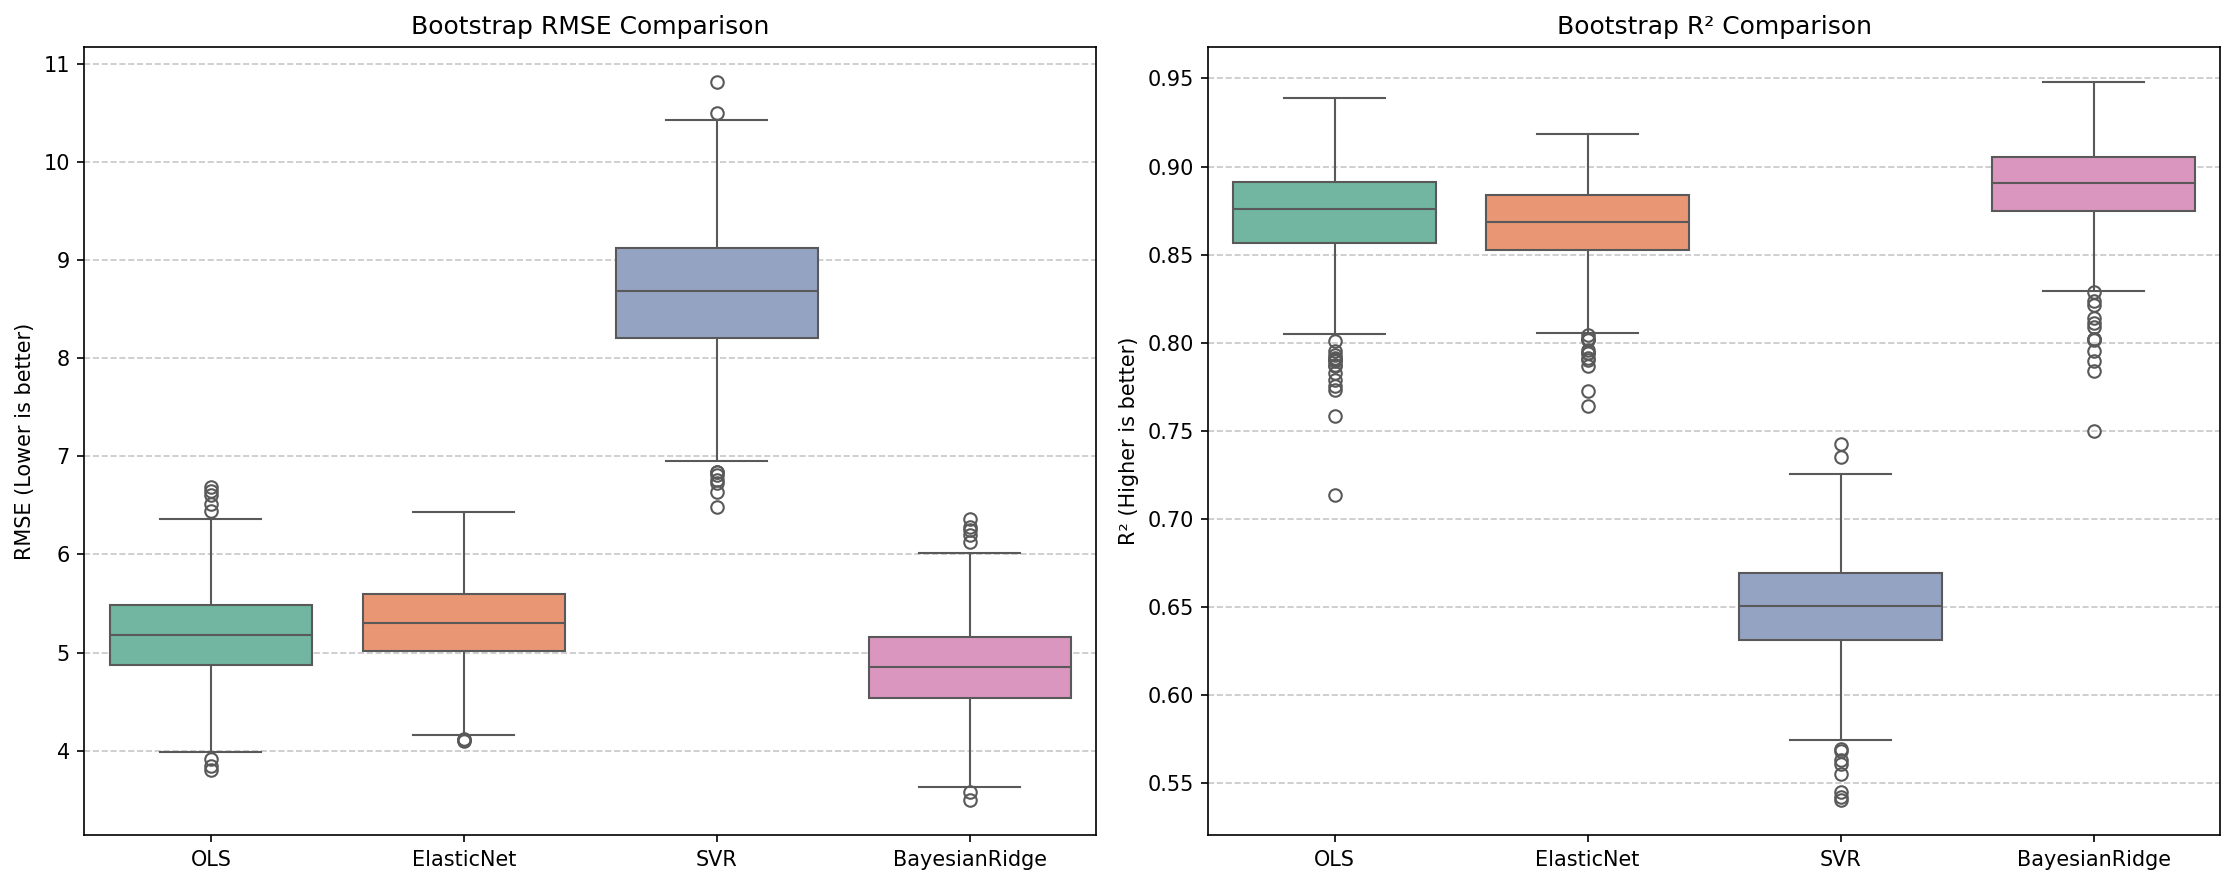

Follow this path to locate the figure: ../figures/ bootstrap_comparison_task22.png


In [12]:
# 150 dpi quality
# Create boxplots for RMSE and R² comparisons
fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=150)

# Create Boxplot for RMSE
sns.boxplot(data=pd.DataFrame(comparison_samples_rmse), ax=axes[0], palette="Set2")
axes[0].set_title("Bootstrap RMSE Comparison")
axes[0].set_ylabel("RMSE (Lower is better)")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Create Boxplot for R²
sns.boxplot(data=pd.DataFrame(comparison_samples_r2), ax=axes[1], palette="Set2")
axes[1].set_title("Bootstrap R² Comparison")
axes[1].set_ylabel("R² (Higher is better)")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

# Save image in figures
plot_path = '../figures/ bootstrap_comparison_task22.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")

In [13]:
# 2. Training & Bootstrap Evaluation
results_22 = []
all_bootstrap_metrics = {} # boxplots

for name, model in models_22.items():
    print(f"Training {name}...")
    
    # 1. Fit
    model.fit(X_train_cpg, y_train)
    
    # 2. Predict
    y_pred = model.predict(X_val_cpg)
    
    # 3. Bootstrap Evaluation (Εδώ χρειαζόμαστε και τα raw bootstrap scores για τα boxplots)
    # Υποθέτω ότι η evaluate_with_bootstrap επιστρέφει και τα samples αν της το ζητήσουμε
    # Αν όχι, θα την τροποποιήσουμε ελαφρώς στο functions.py
    stats = evaluate_with_bootstrap(y_val, y_pred)
    
    # Αποθήκευση για τον τελικό πίνακα
    results_22.append({
        "Model": name,
        "RMSE (95% CI)": f"{stats['rmse'][0]:.3f} [{stats['rmse'][1]:.3f}, {stats['rmse'][2]:.3f}]",
        "MAE (95% CI)":  f"{stats['mae'][0]:.3f} [{stats['mae'][1]:.3f}, {stats['mae'][2]:.3f}]",
        "R² (95% CI)":   f"{stats['r2'][0]:.3f} [{stats['r2'][1]:.3f}, {stats['r2'][2]:.3f}]",
        "Pearson r (95% CI)": f"{stats['pearson_r'][0]:.3f} [{stats['pearson_r'][1]:.3f}, {stats['pearson_r'][2]:.3f}]"
    })
    
    # Κρατάμε τα raw arrays για τα boxplots (πρέπει να βεβαιωθούμε ότι η συνάρτηση τα επιστρέφει)
    all_bootstrap_metrics[name] = stats

# Μετατροπή σε DataFrame και εμφάνιση
df_task_22 = pd.DataFrame(results_22)
display(df_task_22)

Training ElasticNet...
Training SVR...
Training BayesianRidge...


,Model,RMSE (95% CI),MAE (95% CI),R² (95% CI),Pearson r (95% CI)
0,ElasticNet,"5.313 [4.509, 6.171]","4.086 [3.448, 4.791]","0.867 [0.815, 0.908]","0.945 [0.918, 0.966]"
1,SVR,"8.671 [7.363, 9.953]","6.731 [5.700, 7.785]","0.650 [0.590, 0.705]","0.869 [0.818, 0.908]"
2,BayesianRidge,"4.846 [3.925, 5.705]","3.589 [2.965, 4.241]","0.889 [0.837, 0.930]","0.945 [0.918, 0.967]"


# Task 2 : Feature Selection

3.1 Stability Selection

Number of stable features selected: 185


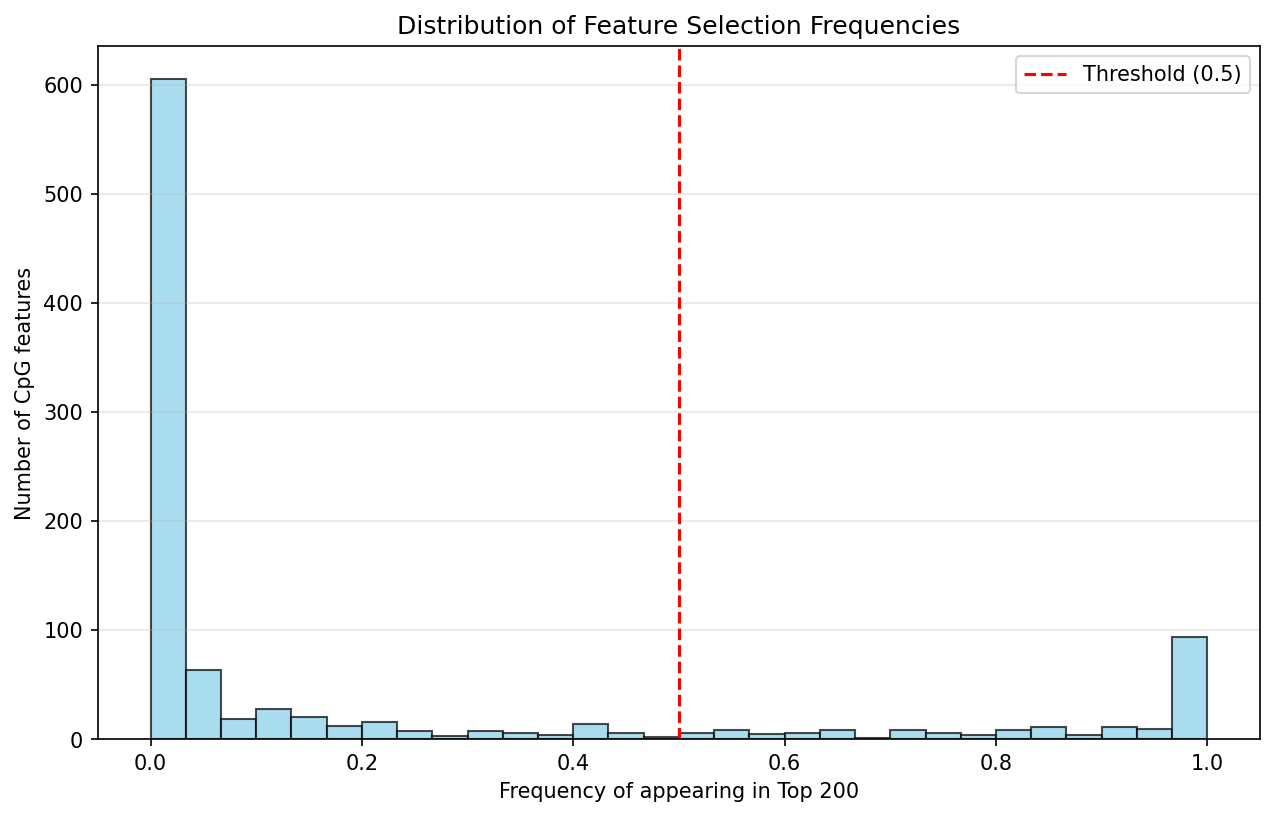

In [14]:
from src.functions import perform_stability_selection
import matplotlib.pyplot as plt

# 1. Implement Stability Selection (using the X_train_cpg which has 1000 features)
stable_indices, freqs = perform_stability_selection(X_train_cpg, y_train.values)

# 2. Stable features names (use the cpg_cols list that have been  created earlier)
selected_cpgs = [cpg_cols[i] for i in stable_indices]

print(f"Number of stable features selected: {len(selected_cpgs)}")

# 3. Report: Selection-frequency distribution (Histogram)
plt.figure(figsize=(10, 6), dpi=150)
plt.hist(freqs, bins=30, edgecolor='black', color='skyblue', alpha=0.7)
plt.axvline(0.5, color='red', linestyle='--', label='Threshold (0.5)')
plt.title("Distribution of Feature Selection Frequencies")
plt.xlabel("Frequency of appearing in Top 200")
plt.ylabel("Number of CpG features")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig("../figures/stability_selection_distribution.png")
plt.show()

# Save the selected features for the next step
# A new dataset with only these features
X_train_stable = X_train_cpg[:, stable_indices]
X_val_stable = X_val_cpg[:, stable_indices]

## 3.2 Minimum Redundancy Maximum Relevance (mRMR)

In [ ]:
# pip install mrmr-selection

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.0/824.0 kB 2.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 6.0 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 3.4 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [mrmr-selection]m [statsmodels]
Note: you may need to restart the kernel to use updated packages.


 mRMR Selection

In [ ]:
# 1. Transformation to DataFrame (mRMR requires column names)
X_train_cpg_df = pd.DataFrame(X_train_cpg, columns=cpg_cols)
y_train_series = pd.Series(y_train.values, name='age')
X_val_cpg_df = pd.DataFrame(X_val_cpg, columns=cpg_cols)

# 2. Loop for finding the best K for mRMR
k_options = [50, 100, 150, 200]
mrmr_results = []

print("Evaluating mRMR for different K...")
for k in k_options:
    # Feature Selection
    selected_mrmr = mrmr_regression(X=X_train_cpg_df, y=y_train_series, K=k, show_progress=False)
    
    # Proxy Model Training (BayesianRidge)
    proxy = BayesianRidge()
    proxy.fit(X_train_cpg_df[selected_mrmr], y_train)
    
    # Prediction on Validation Set
    preds = proxy.predict(X_val_cpg_df[selected_mrmr])
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)
    
    mrmr_results.append({'K': k, 'RMSE': rmse, 'R2': r2, 'features': selected_mrmr})
    print(f"K={k}: RMSE={rmse:.4f}, R2={r2:.4f}")

# 3. Selection of optimal K (Justification)
# We select the one with the lowest RMSE
best_mrmr = min(mrmr_results, key=lambda x: x['RMSE'])
print(f"\nBest mRMR K selected: {best_mrmr['K']}")

Evaluating mRMR for different K...
K=50: RMSE=5.6770, R2=0.8528
K=100: RMSE=5.3766, R2=0.8680
K=150: RMSE=5.2168, R2=0.8757
K=200: RMSE=5.2445, R2=0.8744

Best mRMR K selected: 150


In [20]:
# 4. Retrieving the features for the Best K
# return_scores=True to get the importance scores
output = mrmr_regression(
    X=X_train_cpg_df, 
    y=y_train_series, 
    K=best_mrmr['K'], 
    return_scores=True, 
    show_progress=False
)

# Separate the results
final_mrmr_features = output[0]
mrmr_scores = output[1]

In [ ]:
# 5. Print Top 10 mRMR Features with their Scores
print(f"Top 10 mRMR Features (Selected K={best_mrmr['K']}):")

# Take the names of the first 10 features
top_10_names = final_mrmr_features[:10]

for i, feat in enumerate(top_10_names, 1):
    # Use .loc[feat] because mrmr_scores has the CpG names as the index
    score = mrmr_scores.loc[feat]
    
    # If the score is returned as a Series (due to duplicates or structure), we take the first value
    if hasattr(score, 'values'):
        score = score.values[0]
        
    print(f"{i}. {feat} (Score: {score:.4f})")

Top 10 mRMR Features (Selected K=150):
1. cg16867657 (Score: 832.5694)
2. cg10501210 (Score: 476.6921)
3. cg06639320 (Score: 437.8643)
4. cg24724428 (Score: 444.0341)
5. cg21572722 (Score: 401.1933)
6. cg22454769 (Score: 400.1032)
7. cg19283806 (Score: 286.5906)
8. cg14692377 (Score: 291.1610)
9. cg01974375 (Score: 299.2877)
10. cg07082267 (Score: 282.9775)


In [ ]:
# pip install matplotlib-venn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=84eaf2a83d9f007fde0cca4b541c9d92cd7f8dae8d1ca3f683705df9d06ddb04
  Stored in directory: /home/mdliassa/.cache/pip/wheels/d1/5f/e6/771479559f992b8398265ebf61f8a3d33ca0b8f75552e06ad2
Successfully built matplotlib-venn
Note: you may need to restart the kernel to use updated packages.


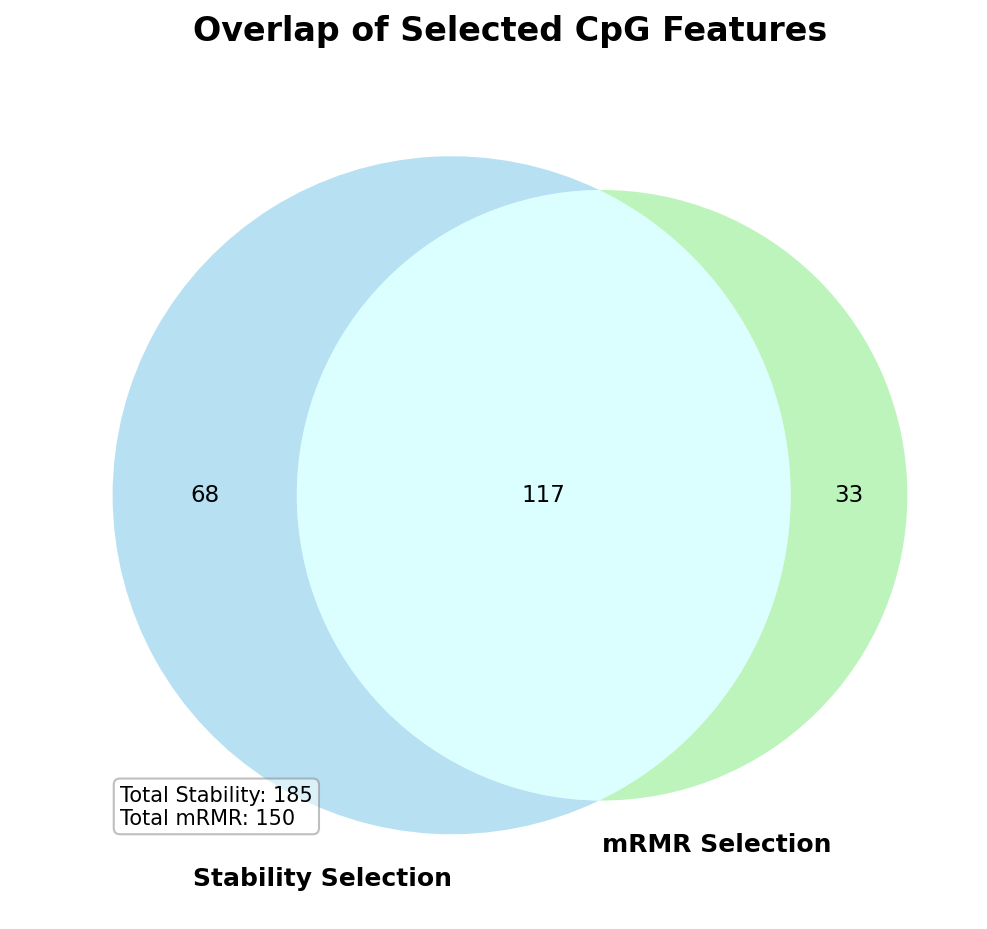

--- Feature Overlap Statistics ---
Common features in both methods: 117
Features unique to Stability: 68
Features unique to mRMR: 33

Note: The top mRMR feature (cg16867657) was also selected by Stability Selection.


In [27]:
plt.figure(figsize=(8, 7), dpi=150)
# Convert lists to sets for the Venn diagram
venn = venn2([stability_set, mrmr_set], 
             set_labels=('Stability Selection', 'mRMR Selection'),
             set_colors=('skyblue', 'lightgreen'), 
             alpha=0.6)

# Label styling
for text in venn.set_labels:
    text.set_fontsize(12)
    text.set_fontweight('bold')

# Style the subset labels
for text in venn.subset_labels:
    if text: # Check if there is text
        text.set_fontsize(11)

plt.title("Overlap of Selected CpG Features\n", fontsize=16, fontweight='bold')

# Add annotation with the sets 
plt.annotate(f'Total Stability: {len(stability_set)}\nTotal mRMR: {len(mrmr_set)}', 
             xy=(0.1, 0.1), xycoords='figure fraction', fontsize=10, 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.5))

plt.savefig("../figures/task3_feature_overlap_venn_fixed.png", bbox_inches='tight')
plt.show()

# 4. Print statistics for the Report
common = stability_set.intersection(mrmr_set)
only_stability = stability_set - mrmr_set
only_mrmr = mrmr_set - stability_set

print(f"--- Feature Overlap Statistics ---")
print(f"Common features in both methods: {len(common)}")
print(f"Features unique to Stability: {len(only_stability)}")
print(f"Features unique to mRMR: {len(only_mrmr)}")

# Check if the top feature (cg16867657) is in both sets
if "cg16867657" in common:
    print("\nNote: The top mRMR feature (cg16867657) was also selected by Stability Selection.")

## 3.3 Method comparison and selection 

In [31]:
from sklearn.linear_model import BayesianRidge
from src.functions import get_bootstrap_samples, calculate_confidence_intervals
# 1. Define the 2 sets  for comparison 
# Use the DataFrames created in 3.2
comparison_sets = {
    "Stability Selection": selected_cpgs,
    "mRMR Selection": final_mrmr_features
}

task3_results = []

print("Running Bootstrap Evaluation for Task 3.3...")

for name, features in comparison_sets.items():
    # Selection of the corresponding columns
    X_train_sub = X_train_cpg_df[features]
    X_val_sub = X_val_cpg_df[features]
    
    # Model training(BayesianRidge)
    model = BayesianRidge()
    model.fit(X_train_sub, y_train)
    
    # Prediction on Validation Set
    y_pred = model.predict(X_val_sub)
    
        # Bootstrap Evaluation using custom function
    boot_metrics = get_bootstrap_samples(y_val, y_pred, n_resamples=1000)
    
    # Calculate confidence intervals from the bootstrap results
    # We use the keys 'rmse' and 'r2' as defined in function
    rmse_stats = calculate_confidence_intervals(boot_metrics['rmse'])
    r2_stats = calculate_confidence_intervals(boot_metrics['r2'])
    
    task3_results.append({
        "Method": name,
        "N Features": len(features),
        "RMSE (Mean)": round(rmse_stats[0], 3),
        "RMSE 95% CI": f"[{rmse_stats[1]:.3f}, {rmse_stats[2]:.3f}]",
        "R² (Mean)": round(r2_stats[0], 3),
        "R² 95% CI": f"[{r2_stats[1]:.3f}, {r2_stats[2]:.3f}]"
    })

# 2. Create and display the final table
df_comparison = pd.DataFrame(task3_results)
print("\n--- Final Comparison Table (Task 3) ---")
display(df_comparison)

Running Bootstrap Evaluation for Task 3.3...

--- Final Comparison Table (Task 3) ---


,Method,N Features,RMSE (Mean),RMSE 95% CI,R² (Mean),R² 95% CI
0,Stability Selection,185,5.108,"[4.206, 6.023]",0.876,"[0.821, 0.921]"
1,mRMR Selection,150,5.199,"[4.475, 5.928]",0.873,"[0.824, 0.911]"


In [33]:
import os

# Create directory to save the csv 
os.makedirs('../results', exist_ok=True)

# Save underthe results directory
df_comparison.to_csv("../results/task3_comparison_table.csv", index=False)
print("Results saved successfully!")
# Save the table to a CSV file for the report
df_comparison.to_csv("../results/task3_comparison_table.csv", index=False)

Results saved successfully!
